# Installing required dependencies

You may skip this step if done previously!

In [1]:
!pip install numpy==1.23.4
!pip install scipy==1.9.3

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.23.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
^C
Defaulting to user installation because normal site-packages is not writeable
^C


In [3]:
!pip install jax==0.4.33
!pip install cachetools==4.2.1
!pip install dp_accounting
!pip install tensorflow_privacy
!pip install tensorflow_compression
!pip install tensorflow_model_optimization
!pip install pyfarmhash
!pip install google-vizier
!pip install mkl-fft==1.3.6

Defaulting to user installation because normal site-packages is not writeable
  Using cached jax-0.4.33-py3-none-any.whl.metadata (22 kB)
  Using cached jaxlib-0.4.33-cp310-cp310-manylinux2014_x86_64.whl.metadata (983 bytes)
  Using cached numpy-2.2.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached jax-0.4.33-py3-none-any.whl (2.1 MB)
Using cached jaxlib-0.4.33-cp310-cp310-manylinux2014_x86_64.whl (85.0 MB)
Using cached numpy-2.2.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.4
    Uninstalling numpy-1.23.4:
      Successfully uninstalled numpy-1.23.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.9.3
    Uninstalling scipy-1.9.3:

In [4]:
!pip install tensorflow-federated

Defaulting to user installation because normal site-packages is not writeable
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jaxlib-0.4.14-cp310-cp310-manylinux2014_x86_64.whl.metadata (2.0 kB)
  Using cached jax-0.4.14-py3-none-any.whl
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.9.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Using cached numpy-1.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached jaxlib-0.4.14-cp310-cp310-manylinux2014_x86_64.whl (73.7 MB)
Using cached cachetools-5.5.2-py3-none-any.whl (10 kB)
Using cached scipy-1.9.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (33.7 MB)
Using cached numpy-1.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy

# Loading the dataset

In [3]:
import tensorflow_federated as tff
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

2025-04-03 10:23:10.369859: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 10:23:10.623726: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-03 10:23:10.623763: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-03 10:23:10.624933: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 10:23:10.732386: I tensorflow/core/platform/cpu_feature_g

In [7]:
df = pd.read_csv("combined_dataset.csv")
# df = pd.read_csv("preprocessed.csv")


<AxesSubplot: title={'center': 'Class Distribution'}>

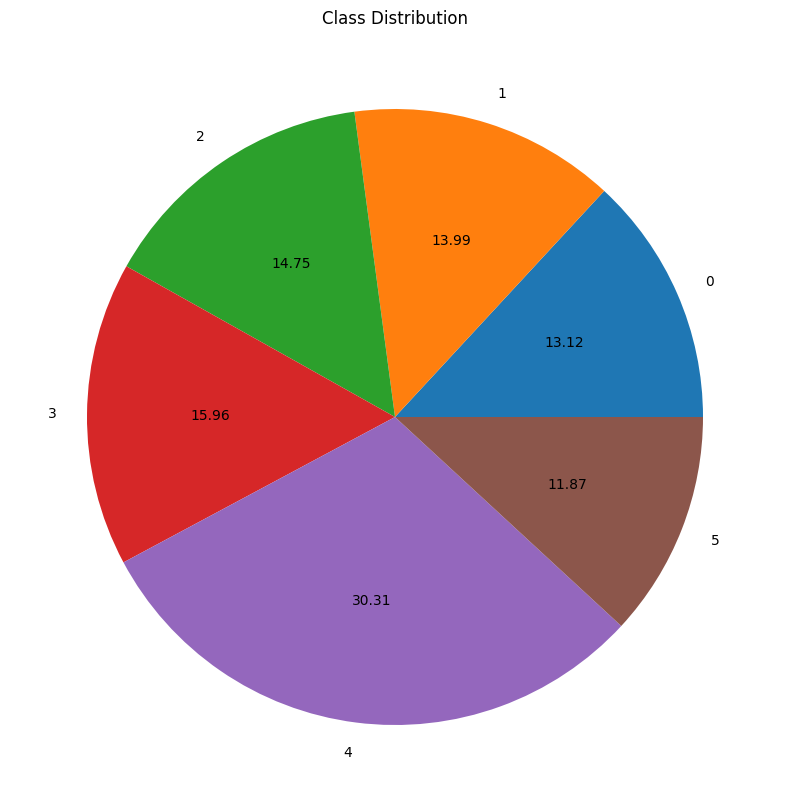

In [3]:
from matplotlib import pyplot as plt

plt.title("Class Distribution")
df.groupby("type").size().plot(kind='pie', autopct='%.2f', figsize=(20,10))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501412 entries, 0 to 501411
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             501412 non-null  int64  
 1   H_L0.1_weight          501412 non-null  float64
 2   H_L0.01_weight         501412 non-null  float64
 3   H_L0.01_mean           501412 non-null  float64
 4   H_L0.01_variance       501412 non-null  float64
 5   HH_L3_covariance       501412 non-null  float64
 6   HH_L3_pcc              501412 non-null  float64
 7   HH_L1_std              501412 non-null  float64
 8   HH_L1_radius           501412 non-null  float64
 9   HH_L1_covariance       501412 non-null  float64
 10  HH_L1_pcc              501412 non-null  float64
 11  HH_L0.1_std            501412 non-null  float64
 12  HH_L0.1_radius         501412 non-null  float64
 13  HH_L0.1_covariance     501412 non-null  float64
 14  HH_L0.1_pcc            501412 non-nu

In [5]:
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.head()

,Unnamed: 0,H_L0.1_weight,H_L0.01_weight,H_L0.01_mean,H_L0.01_variance,HH_L3_covariance,HH_L3_pcc,HH_L1_std,HH_L1_radius,HH_L1_covariance,...,HpHp_L0.1_radius,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,type,client_id
0,0,0.722600,0.730815,0.243559,0.121941,0.40019,0.465515,1.582986e-08,1.850157e-16,0.375233,...,0.000000e+00,0.447814,0.000000,0.000000e+00,3.503546e-01,0.000000e+00,0.57339,0.470035,4,4
1,1,0.000174,0.000767,0.049924,0.069024,0.40019,0.465515,9.888532e-10,7.231190e-19,0.375233,...,9.499373e-19,0.447814,0.000161,2.217323e-09,2.081668e-17,4.739318e-18,0.57339,0.470035,0,5
2,2,0.431151,0.340274,0.005537,0.000108,0.40019,0.465515,0.000000e+00,0.000000e+00,0.375233,...,0.000000e+00,0.447814,0.000000,0.000000e+00,2.081668e-17,0.000000e+00,0.57339,0.470035,3,5
3,3,0.562914,0.448512,0.208682,0.132518,0.40019,0.465515,0.000000e+00,0.000000e+00,0.375233,...,0.000000e+00,0.447814,0.000000,0.000000e+00,2.081668e-17,0.000000e+00,0.57339,0.470035,5,4
4,4,0.249354,0.292245,0.000016,0.000002,0.40019,0.465515,0.000000e+00,0.000000e+00,0.375233,...,0.000000e+00,0.447814,0.000000,0.000000e+00,2.081668e-17,0.000000e+00,0.57339,0.470035,2,1


In [6]:
len(df)

501412

### Data Preprocessing Steps
The dataset has been preprocessed using the following steps:
1. **Min-Max Scaling:** Applied to normalize numerical features within the range [0, 1].
2. **Label Encoding:** Categorical target labels were encoded into numerical values for model compatibility.

This preprocessing ensures data consistency and improves model performance.

In [97]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

features = list(df.columns)
features.remove("type")
features.remove("client_id")

label_encoder = LabelEncoder()
df["type"] = label_encoder.fit_transform(df["type"])

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

df[features] = df[features].astype("float32")

df["type"] = df["type"].astype("int32")

In [7]:
df.head()

,H_L0.1_weight,H_L0.01_weight,H_L0.01_mean,H_L0.01_variance,HH_L3_covariance,HH_L3_pcc,HH_L1_std,HH_L1_radius,HH_L1_covariance,HH_L1_pcc,...,HpHp_L0.1_radius,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,type,client_id
0,0.630546,0.180265,0.007036,0.000097,0.40019,0.465515,2.061778e-07,3.138617e-14,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,9.929078e-03,0.0,0.57339,0.470035,3,4
1,0.707835,0.958647,0.244745,0.121416,0.40019,0.465515,1.021808e-04,7.708914e-09,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,3.503546e-01,0.0,0.57339,0.470035,4,4
2,0.726351,0.978854,0.244358,0.121589,0.40019,0.465515,2.985429e-06,6.580637e-12,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,3.503546e-01,0.0,0.57339,0.470035,4,4
3,0.251774,0.346630,0.000015,0.000002,0.40019,0.465515,0.000000e+00,0.000000e+00,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,2,4
4,0.223678,0.292419,0.000076,0.000004,0.40019,0.465515,0.000000e+00,0.000000e+00,0.375233,0.457158,...,0.0,0.447814,0.0,0.0,2.081668e-17,0.0,0.57339,0.470035,2,5


### Feature Engineering and Dimensionality Reduction
In this step, the dataset is processed to remove redundant and less informative features:

1. **Constant Features Removal:**  
   - Identified features with only one unique value across all samples. These provide no useful information and are removed.

2. **Highly Correlated Features Removal:**  
   - A correlation matrix is computed to detect features with a correlation above **0.95**.  
   - Among highly correlated features, only one feature from each correlated group is retained to reduce redundancy.

3. **Handling Missing Values:**  
   - Features with more than **80% missing values** are identified and removed to ensure data quality.

4. **Final Reduction:**  
   - The combined list of constant, redundant, and missing-heavy features is dropped, resulting in a more compact and efficient dataset.

In [99]:
import pandas as pd
import numpy as np

# Find constant features
constant_features = [col for col in df.columns if df[col].nunique() == 1]

corr_matrix = df.corr().abs()

# Create a mask to identify redundant features
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify features that are highly correlated
to_drop = set()

for column in upper_tri.columns:
    high_corr_features = upper_tri.index[upper_tri[column] > 0.95].tolist()
    
    # If this column is not already in the drop list, keep it and drop others
    if column not in to_drop:
        to_drop.update(high_corr_features)

# Drop only redundant features while keeping one from each correlated group
df_reduced = df.drop(columns=to_drop)

# Find features with too many missing values
missing_features = [col for col in df.columns if df[col].isnull().sum() / len(df) > 0.8]

# Combine all
features_to_remove = list(set(constant_features + high_corr_features + missing_features))

corr_matrix = df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Count of missing features: {missing_features}")
print(f"Count of highly correlated features: {len(high_corr_features)}")
print(f"Count of constant features: {constant_features}")
print("Features to remove:", len(features_to_remove))

print(f"Original features: {df.shape[1]}")
print(f"Reduced features: {df_reduced.shape[1]}")
print(f"Dropped features: {len(to_drop)}")


Count of missing features: []
Count of highly correlated features: 81
Count of constant features: []
Features to remove: 0
Original features: 117
Reduced features: 36
Dropped features: 81


In [100]:
df = df_reduced

In [26]:
df.to_csv("preprocessed.csv")

### Federated Data Preparation and Logical Split
In this section, the dataset is prepared for federated learning with a client-based distribution strategy. The steps are as follows:

1. **Data Splitting with Client Preservation:**  
   - The dataset is split into **80% training** and **20% testing** sets.  
   - The `stratify=y` parameter ensures the class distribution remains balanced in both splits.  
   - The `client_id` values are preserved to ensure each client's data remains logically grouped.

2. **TensorFlow Dataset Conversion:**  
   - Each partition is converted into a TensorFlow dataset using `tf.data.Dataset`.  
   - Datasets are shuffled and batched with a size of **32** for efficient training.

3. **Federated Data Creation:**  
   - The `create_federated_data()` function groups data by client ID.  
   - Each client receives its own data partition, ensuring realistic federated learning conditions.

4. **Client Simulation:**  
   - The resulting federated dataset mimics the real-world distribution of data across multiple clients.  
   - This setup is essential for evaluating federated algorithms like **FedAvg** and **FedProx** under diverse data conditions.

In [5]:
from sklearn.model_selection import train_test_split

# Assuming `df` contains features, target (`type`), and `client_id`)
X = df.drop(columns=['type', 'client_id'])  
y = df['type']
client_ids = df['client_id']

# Split dataset (80% training, 20% testing) while preserving client_id alignment
X_train, X_test, y_train, y_test, client_train_ids, client_test_ids = train_test_split(
    X, y, client_ids, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convert Pandas DataFrame to TensorFlow Dataset
def create_tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(20)  # Adjust batch size if needed
    return dataset

def create__tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(6)  # Adjust batch size if needed
    return dataset

# Group data by client_id to ensure logical data split
def create_federated_data(X, y, client_ids):
    federated_data = []
    unique_clients = client_ids.unique()
    
    for client in unique_clients:
        client_X = X[client_ids == client]
        client_y = y[client_ids == client]
        federated_data.append(create_tf_dataset(client_X, client_y))
    
    return federated_data

# Create federated datasets
train_dataset = create_tf_dataset(X_train, y_train)
test_dataset = create__tf_dataset(X_test, y_test)

# Simulate federated client datasets
NUM_CLIENTS = 5  # Adjust based on your needs

client_data = create_federated_data(X_train, y_train, client_train_ids)

Train shape: (248587, 34), Test shape: (62147, 34)


In [6]:
train_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 34), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['type', 'client_id'])
y = df['type']
client_ids = df['client_id']

# Split dataset (80% training, 20% testing) while preserving client_id alignment
X_train, X_test, y_train, y_test, client_train_ids, client_test_ids = train_test_split(
    X, y, client_ids, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convert Pandas DataFrame to TensorFlow Dataset
def create_tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(32)
    return dataset
    
def create_test_tf_dataset(X, y):
    dataset = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(10)
    return dataset

# Non-IID Data Splitting Function (Improved Version)
def improved_non_iid_split(X, y, client_ids, num_clients=5, overlap_ratio=0.1):
    attack_classes = y.unique()
    np.random.shuffle(attack_classes)

    client_data = {i: {'X': [], 'y': []} for i in range(num_clients)}

    # Step 1: Assign one common attack type to all clients
    common_attack = np.random.choice(attack_classes)
    common_indices = np.array(y[y == common_attack].index)
    np.random.shuffle(common_indices)

    # Distribute common attack samples evenly
    common_split = np.array_split(common_indices, num_clients)
    for i in range(num_clients):
        client_data[i]['X'].append(X.loc[common_split[i]])
        client_data[i]['y'].append(y.loc[common_split[i]])

    # Step 2: Assign remaining attacks
    assigned_attacks = [common_attack]
    for i in range(num_clients - 1):
        available_attacks = [a for a in attack_classes if a not in assigned_attacks]
        
        # Fix: Ensure selected size is valid
        size = min(len(available_attacks), np.random.choice([1, 2]))
        selected_attacks = np.random.choice(available_attacks, size=size, replace=False)
    
        assigned_attacks.extend(selected_attacks)
        for attack in selected_attacks:
            attack_indices = np.array(y[y == attack].index)
            np.random.shuffle(attack_indices)
    
            client_data[i]['X'].append(X.loc[attack_indices])
            client_data[i]['y'].append(y.loc[attack_indices])


    # Step 3: Introduce controlled overlap (without increasing total samples)
    total_existing_samples = sum(len(pd.concat(client_data[i]['X'])) for i in range(num_clients))
    excess_samples = total_existing_samples - len(X)

    if excess_samples > 0:
        # Reduce each client's data proportionally
        for i in range(num_clients):
            current_size = len(pd.concat(client_data[i]['X']))
            reduction_size = int((current_size / total_existing_samples) * excess_samples)

            client_data[i]['X'] = [X.iloc[:-reduction_size] for X in client_data[i]['X']]
            client_data[i]['y'] = [y.iloc[:-reduction_size] for y in client_data[i]['y']]

    # Combine client data
    total_samples = 0
    federated_data = []
    for i in range(num_clients):
        if client_data[i]['X']:  # Prevent empty dataframes
            client_X = pd.concat(client_data[i]['X'])
            client_y = pd.concat(client_data[i]['y'])
            federated_data.append(create_tf_dataset(client_X, client_y))

            # Print confirmation
            print(f"Client {i} - Samples: {len(client_X)} | Unique Attacks: {client_y.unique()}")

            total_samples += len(client_X)

    print(f"\n✅ Total Samples in Federated Data: {total_samples}")
    print(f"✅ Original Dataset Samples: {len(X)}")

    return federated_data
    
# Create federated datasets
train_dataset = create_tf_dataset(X_train, y_train)
test_dataset = create_test_tf_dataset(X_test, y_test)

# Create improved non-IID federated datasets
client_data = improved_non_iid_split(X_train, y_train, client_train_ids, num_clients=5)


/home/soham/.local/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


NameError: name 'df' is not defined

### 📊 Visualization Code Explanation

This code generates two key visualizations to analyze the **non-IID data distribution** across clients:

1️⃣ **Total Data Per Client:**  
- Displays the total number of data points held by each client using a bar plot.  
- Helps identify clients with **imbalanced data sizes**.

2️⃣ **Attack Type Distribution per Client (Stacked Bar Chart):**  
- Groups data by `client_id` and `type` to show the distribution of attack types within each client.  
- The stacked bar chart reveals the **non-IID nature** of the data by visualizing dominant and minority attack types.

### 🔹 Key Insights:
- Detect **data imbalance** across clients.
- Identify clients with **rare attack types** or **low data volumes**.
- Useful for refining strategies like client re-weighting or model architecture adjustments.

/tmp/ipykernel_35754/480699604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=client_counts.index, y=client_counts.values, palette="viridis")


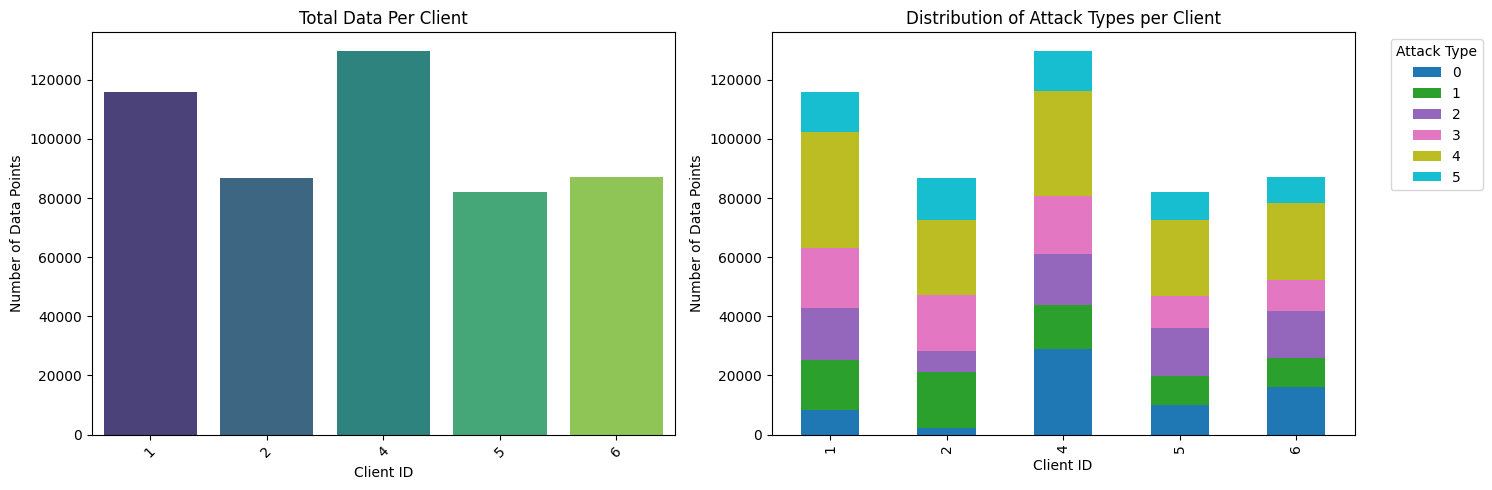

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df contains 'client_id' and 'type' columns
plt.figure(figsize=(15, 5))

# 1️⃣ Total Data Per Client
plt.subplot(1, 2, 1)
client_counts = df['client_id'].value_counts()
sns.barplot(x=client_counts.index, y=client_counts.values, palette="viridis")
plt.xlabel("Client ID")
plt.ylabel("Number of Data Points")
plt.title("Total Data Per Client")
plt.xticks(rotation=45)

# 2️⃣ Attack Type Distribution per Client (Stacked Bar Chart)
plt.subplot(1, 2, 2)
client_attack_counts = df.groupby(["client_id", "type"]).size().unstack()
client_attack_counts.plot(kind="bar", stacked=True, colormap="tab10", ax=plt.gca())
plt.xlabel("Client ID")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Attack Types per Client")
plt.legend(title="Attack Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


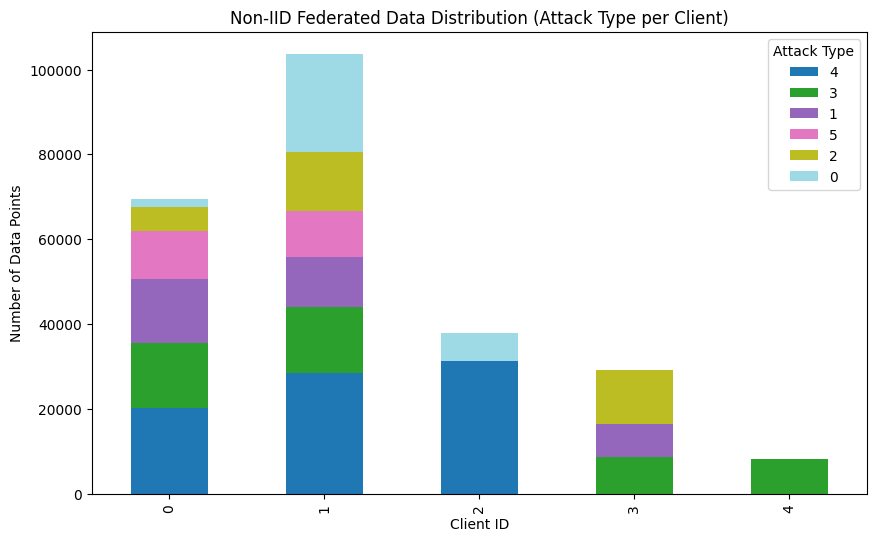

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization of Non-IID Data Distribution
def visualize_federated_data(client_data, y_train, client_train_ids):
    client_distribution = {}

    # Extract class counts per client
    for i, dataset in enumerate(client_data):
        y_values = np.concatenate([y.numpy() for _, y in dataset])
        class_counts = pd.Series(y_values).value_counts().to_dict()
        client_distribution[i] = class_counts

    # Convert to DataFrame for plotting
    dist_df = pd.DataFrame(client_distribution).fillna(0).astype(int)

    # Plotting
    dist_df.T.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6),
        colormap='tab20'
    )

    plt.title('Non-IID Federated Data Distribution (Attack Type per Client)')
    plt.xlabel('Client ID')
    plt.ylabel('Number of Data Points')
    plt.legend(title='Attack Type')
    plt.show()

visualize_federated_data(client_data, y_train, client_train_ids)


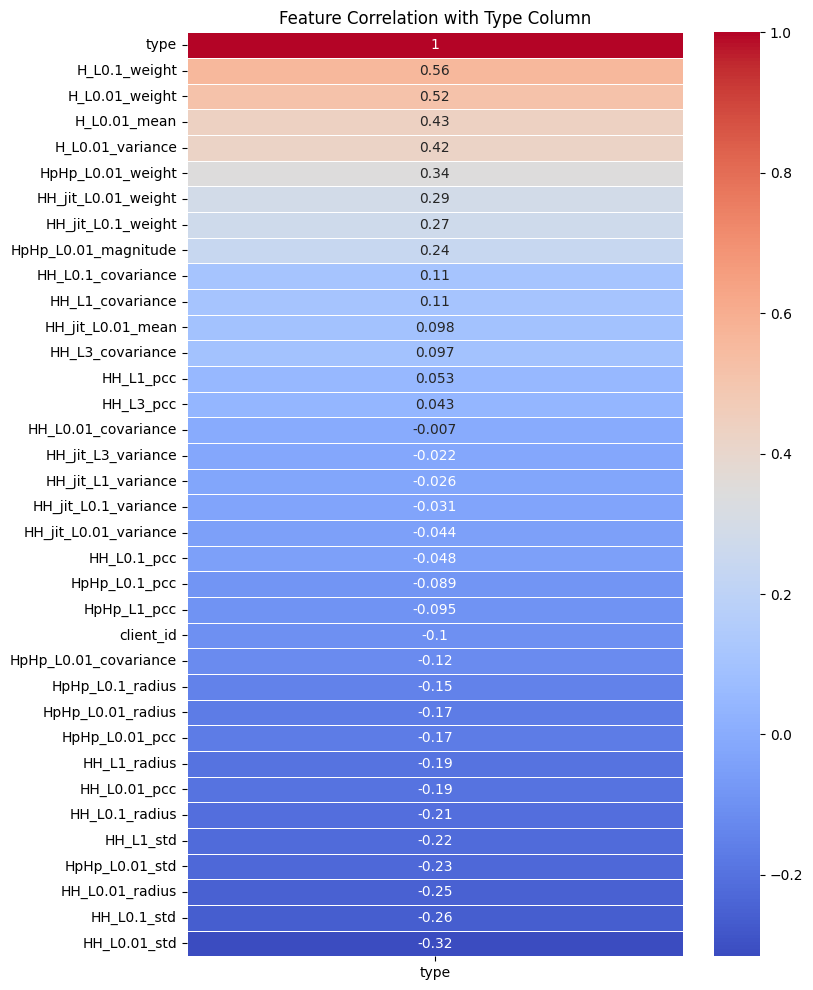

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute correlation matrix
corr_matrix = df.corr()

# Extract correlations with 'type' column and sort
type_corr = corr_matrix[['type']].sort_values(by='type', ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(type_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation with Type Column")
plt.show()


## 1. CNN Model

In [129]:
X_train.shape[1]

34

In [25]:
def create_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(y_train.unique()), activation='sigmoid')
    ])
    return model

## 2. ANN Model

In [5]:
def create_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(X_train.shape[1], 1)),

        layers.Dense(256, activation='relu'),
        layers.LayerNormalization(),  # Slower momentum for stable FL updates
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.LayerNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(len(y_train.unique()), activation='softmax')
    ])
    return model

## 3. RNN Model

In [5]:
def create_model():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1], 1)),
        layers.SimpleRNN(128, return_sequences=True),
        layers.SimpleRNN(64),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(y_train.unique()), activation='softmax')
    ])
    return model

### Model Function for TensorFlow Federated (TFF)

The `model_fn()` function defines the model for use in TensorFlow Federated (TFF).

- **`create_model()`**: This function constructs and returns a Keras model with the desired architecture.  
- **`tff.learning.models.from_keras_model`**: This method adapts the Keras model for TFF by specifying:
  - `keras_model`: The created Keras model.  
  - `input_spec`: The input data specification derived from `client_data[0].element_spec` to ensure the model matches the data format.  
  - `loss`: The loss function used during training, set to `SparseCategoricalCrossentropy()` for multi-class classification with integer-encoded labels.  
  - `metrics`: Evaluation metrics such as `SparseCategoricalAccuracy()` to track model performance.  

This function is essential for TFF since it ensures compatibility with the federated learning framework by defining the model's structure, input shape, and evaluation criteria.


In [6]:
def model_fn():
    keras_model = create_model()
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=client_data[0].element_spec,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

In [27]:
# Define FedAvg parameters
client_optimizer_fn = tff.learning.optimizers.build_sgdm(learning_rate=0.025)
server_optimizer_fn = tff.learning.optimizers.build_sgdm(learning_rate=0.5)

iterative_process = tff.learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,  # Your model function
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [83]:
# Define FedProx parameters
proximal_strength = 0.01  # Adjust based on experimentation
client_optimizer_fn = tff.learning.optimizers.build_sgdm(learning_rate=0.05)
server_optimizer_fn = tff.learning.optimizers.build_sgdm(learning_rate=0.5)

# Build the FedProx iterative process
iterative_process = tff.learning.algorithms.build_weighted_fed_prox(
    model_fn=model_fn,
    proximal_strength=proximal_strength,
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

In [13]:
# Define FedAdam parameters
client_optimizer_fn = tff.learning.optimizers.build_adam(learning_rate=0.0001)
server_optimizer_fn = tff.learning.optimizers.build_sgdm(learning_rate=0.5)

# Build the FedAdam iterative process
iterative_process = tff.learning.algorithms.build_weighted_fed_avg(
    model_fn=model_fn,  # Your model function
    client_optimizer_fn=client_optimizer_fn,
    server_optimizer_fn=server_optimizer_fn
)

Hello
3108/3108 [==============================] - 11s 3ms/step


/home/soham/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Round 1:
 - Metrics: OrderedDict([('distributor', ()), ('client_work', OrderedDict([('train', OrderedDict([('sparse_categorical_accuracy', 0.87318724), ('loss', 0.30608472), ('num_examples', 248587), ('num_batches', 12432)]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', OrderedDict([('update_non_finite', 0)]))])
 - Loss: 0.9918, Accuracy: 0.6847
 - Precision: 0.1513, Recall: 0.1659, F1-score: 0.1533
 - Time Taken: 82.03 seconds
 - Communication Cost: 400 Bytes
--------------------------------------------------
3108/3108 [==============================] - 13s 4ms/step
Round 2:
 - Metrics: OrderedDict([('distributor', ()), ('client_work', OrderedDict([('train', OrderedDict([('sparse_categorical_accuracy', 0.9030842), ('loss', 0.20665662), ('num_examples', 248587), ('num_batches', 12432)]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', OrderedDict([('update_non_finite', 0)]))])
 - Loss: 0.6423, Accura

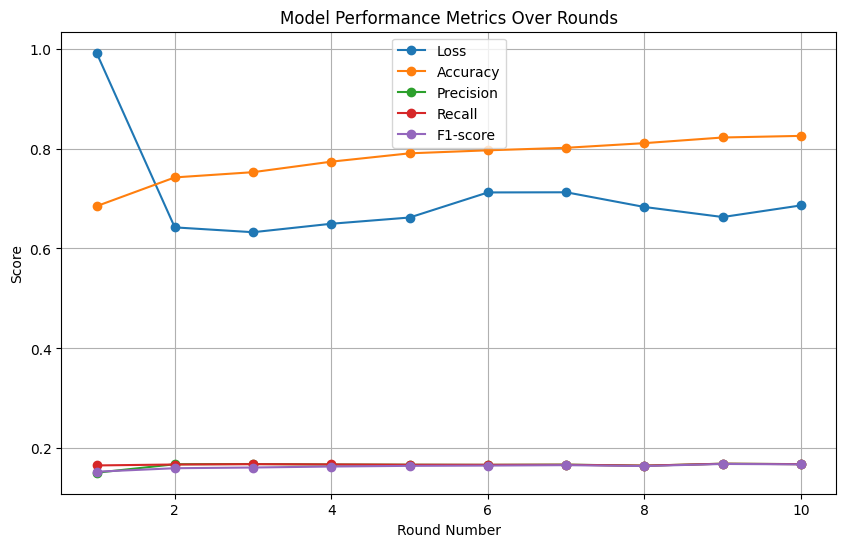

In [27]:
import time
import sys

# state = iterative_process.initialize()

# NUM_ROUNDS = 10  # Adjust based on requirement
# for round_num in range(NUM_ROUNDS):
#     start_time = time.time()

#     # Run one round of federated training
#     state, metrics = iterative_process.next(state, client_data)

#     end_time = time.time()
#     round_time = end_time - start_time

#     # Compute communication cost (approximate)
#     model_size_bytes = sys.getsizeof(state)  # Get memory size of model state
#     communication_cost = model_size_bytes * len(client_data)  # Total cost

#     print(f"Round {round_num+1}:")
#     print(f" - Metrics: {metrics}")
#     print(f" - Time Taken: {round_time:.2f} seconds")
#     print(f" - Communication Cost: {communication_cost} Bytes")
#     print("-" * 50)

import time
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize metrics tracking lists
losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []



print("Hello")

state = iterative_process.initialize()

NUM_ROUNDS = 10  # Adjust based on requirement
for round_num in range(NUM_ROUNDS):
    start_time = time.time()

    # Run one round of federated training
    state, metrics = iterative_process.next(state, client_data)
    
    # Extract trained model weights
    trained_weights = state.global_model_weights.trainable
    
    # Create a new model instance
    final_model = create_model()  # Ensure this function returns an uncompiled Keras model
    final_model.set_weights(trained_weights)

    final_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),  # Matches FedProx params
                    loss='sparse_categorical_crossentropy',  # Adjust if one-hot encoding is used
                    metrics=['accuracy'])

    end_time = time.time()
    round_time = end_time - start_time

    # Compute communication cost (approximate)
    model_size_bytes = sys.getsizeof(state)  # Get memory size of model state
    communication_cost = model_size_bytes * len(client_data)  # Total cost

    # Evaluate model on test dataset
    loss, accuracy = final_model.evaluate(test_dataset)
    y_true = np.concatenate([labels.numpy() for _, labels in test_dataset], axis=0)
    y_pred = final_model.predict(test_dataset).argmax(axis=1)[:len(y_true)]  # Align predictions to match y_true

    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    # Store metrics for plotting
    losses.append(loss)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    print(f"Round {round_num+1}:")
    print(f" - Metrics: {metrics}")
    print(f" - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
    print(f" - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    print(f" - Time Taken: {round_time:.2f} seconds")
    print(f" - Communication Cost: {communication_cost} Bytes")
    print("-" * 50)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_ROUNDS + 1), losses, label='Loss', marker='o')
plt.plot(range(1, NUM_ROUNDS + 1), accuracies, label='Accuracy', marker='o')
plt.plot(range(1, NUM_ROUNDS + 1), precisions, label='Precision', marker='o')
plt.plot(range(1, NUM_ROUNDS + 1), recalls, label='Recall', marker='o')
plt.plot(range(1, NUM_ROUNDS + 1), f1_scores, label='F1-score', marker='o')

plt.title('Model Performance Metrics Over Rounds')
plt.xlabel('Round Number')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


### **Loading Trained Weights and Evaluating a Model**

This code demonstrates how to load trained model weights into a new model instance and evaluate its performance.

1. **Extract Trained Weights:**  
   - `state.global_model_weights.trainable` contains the model's trained weights from the federated learning process.

2. **Create a New Model Instance:**  
   - `create_model()` should define the same architecture used during training.  
   - The new model is uncompiled since `.set_weights()` directly assigns the weights.

3. **Load Trained Weights:**  
   - `.set_weights()` applies the extracted weights to the new model.

4. **Evaluate the Model:**  
   Predictions are generated and evaluated using common metrics such as:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1 Score**

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from tqdm import tqdm

# Extract trained model weights
trained_weights = state.global_model_weights.trainable

# Create a new model instance
final_model = create_model()  # Ensure this function returns an uncompiled Keras model

# Set the trained weights
final_model.set_weights(trained_weights)


### FedAvg and FedProx

In [16]:
final_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),  # Matches FedProx params
                    loss='sparse_categorical_crossentropy',  # Adjust if one-hot encoding is used
                    metrics=['accuracy'])

### FedAdam

In [17]:
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005,  # Start small; can adjust based on convergence
        beta_1=0.9,
        beta_2=0.99,
        epsilon=1e-8),  # Matches FedProx params
                    loss='sparse_categorical_crossentropy',  # Adjust if one-hot encoding is used
                    metrics=['accuracy'])

In [20]:
# Evaluate on test dataset
loss, accuracy = final_model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")

# Convert test dataset into numpy arrays
y_true = []
y_pred = []

total_batches = sum(1 for _ in test_dataset)  # Calculate total batches for accurate progress bar

for X_batch, y_batch in tqdm(test_dataset, total=total_batches, desc="Processing Batches"):
    y_batch_pred = final_model.predict(X_batch, verbose=0)  # Suppress excessive logs
    y_pred.append(np.argmax(y_batch_pred, axis=1))  # Efficient batch-wise append
    y_true.append(y_batch.numpy())  # Efficient batch-wise append

# Flatten the lists
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Compute classification metrics
precision = precision_score(y_true, y_pred, average='macro')  # Use 'micro' or 'weighted' if needed
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

In [21]:
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")

Test Accuracy: 0.8215
Test Precision: 0.7875
Test Recall: 0.7846
Test F1-score: 0.7843


In [40]:
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")

Test Accuracy: 0.8373
Test Precision: 0.8057
Test Recall: 0.7985
Test F1-score: 0.7924


In [121]:
import pandas as pd

# Load the dataset
df = pd.read_csv("preprocessed.csv")

# Define filtering conditions
client_conditions = {
    1: [0, 4],                # Client 0 → Blue (Attack Type 0) and Attack Type 4
    2: list(range(6)),        # Client 1 → All attack types
    4: list(range(6)),        # Client 2 → All attack types
    5: [2, 3, 1],             # Client 3 → Purple (2), Pink (3), and Yellow (1)
    6: [3]                    # Client 4 → Pink (Attack Type 3)
}

# Save filtered data for each client
for client_id, attack_types in client_conditions.items():
    client_data = df[(df['client_id'] == client_id) & (df['type'].isin(attack_types))].drop(columns=["Unnamed: 0"]) 
                      # Remove 'client_id' as requested
    client_data.to_csv(f"client_{client_id}.csv", index=False)
    print(f"Client {client_id} data saved with shape: {client_data.shape}")

Client 1 data saved with shape: (47388, 36)
Client 2 data saved with shape: (86801, 36)
Client 4 data saved with shape: (129604, 36)
Client 5 data saved with shape: (36678, 36)
Client 6 data saved with shape: (10263, 36)


In [123]:
import pandas as pd
import glob  # For fetching multiple files easily

# List of CSV file names
file_paths = [f"client_{i}.csv" for i in range(1,6)]

# Read and concatenate the CSV files
combined_df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

# Save the combined dataset
combined_df.to_csv("combined_dataset.csv", index=False)

print(f"Combined dataset saved with shape: {combined_df.shape}")


Combined dataset saved with shape: (310734, 36)


In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the combined dataset
df = pd.read_csv("preprocessed.csv")

# Split data into train (80%) and test (20%)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['type'])

# Save the test dataset
test_df.to_csv("test_dataset.csv", index=False)

print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print("Test dataset saved as 'test_dataset.csv'")

Train dataset shape: (401129, 37)
Test dataset shape: (100283, 37)
Test dataset saved as 'test_dataset.csv'
